We have a model that can give us SPoSE embeddings for any given image. Now let's take a look at the features that characterize the most-memorable and least-memorable images in the THINGS dataset. 

ResMem SRCC w/ THINGS memorability:       ρ = 0.276

CLIP-HBA-Mem SRCC w/ THINGS memorability: ρ = 

In [4]:
import pandas as pd
import os
from pathlib import Path

# Paths to each fold's predictions
inference_dir = Path("../CLIP-HBA-Mem_final/inference")
fold_dirs = sorted(inference_dir.glob("things_clip_hba_mem_fold*"))
print(f"Found {len(fold_dirs)} fold directories with predictions.")

# Load all fold predictions and extract top-10 most memorable per fold
top10_per_fold = {}
all_top10_rows = []
for fold_dir in fold_dirs:
    csv_path = fold_dir / "things_predictions.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        fold_name = fold_dir.name  # e.g. things_clip_hba_mem_fold1_...
        fold_num = fold_name.split("_fold")[1].split("_")[0]
        top10 = df.nlargest(10, "pred_score").reset_index(drop=True)
        top10["fold"] = int(fold_num)
        top10_per_fold[int(fold_num)] = top10
        all_top10_rows.append(top10)

# Flatten all top-10 rows into a single DataFrame and filter to unique images
all_top10_df = pd.concat(all_top10_rows, ignore_index=True)
unique_top10 = all_top10_df.drop_duplicates(subset="image_path").sort_values(
    "pred_score", ascending=False).reset_index(drop=True)
print(f"\nUnique top-10 most-memorable images across all 10 folds: {len(unique_top10)}")
display(unique_top10[["image_path", "pred_score", "true_score"]])

Found 10 fold directories with predictions.

Unique top-10 most-memorable images across all 10 folds: 31


,image_path,pred_score,true_score
0,knot/knot_12s.jpg,1.078049,0.725000
1,turban/turban_06s.jpg,1.076689,0.950000
2,swimsuit/swimsuit_10s.jpg,1.075354,0.878049
3,eraser/eraser_09s.jpg,1.070586,0.871795
4,screw/screw_10s.jpg,1.065356,0.878049
5,bracelet1/bracelet1_03s.jpg,1.064344,0.897436
6,bracket/bracket_13s.jpg,1.060998,0.700000
7,footprint/footprint_10s.jpg,1.060865,0.789474
8,turban/turban_11s.jpg,1.058679,0.846154
9,turban/turban_12s.jpg,1.055914,0.928571


In [5]:
# Extract bottom-10 least memorable images per fold, then get unique set across all folds
bottom10_per_fold = {}
all_bottom10_paths = []
for fold_dir in fold_dirs:
    csv_path = fold_dir / "things_predictions.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        fold_name = fold_dir.name
        fold_num = fold_name.split("_fold")[1].split("_")[0]
        bottom10 = df.nsmallest(10, "pred_score").reset_index(drop=True)
        bottom10_per_fold[int(fold_num)] = bottom10
        all_bottom10_paths.extend(bottom10["image_path"].tolist())

# Unique bottom-10 least-memorable images across all folds
unique_bottom10 = pd.DataFrame({"image_path": sorted(set(all_bottom10_paths))})
print(f"Unique bottom-10 images across all 10 folds: {len(unique_bottom10)}")
display(unique_bottom10)

Unique bottom-10 images across all 10 folds: 24


,image_path
0,altar/altar_11n.jpg
1,altar/altar_17n.jpg
2,boulder/boulder_19s.jpg
3,branch/branch_12s.jpg
4,bush/bush_02s.jpg
5,ferry/ferry_12s.jpg
6,flagpole/flagpole_05s.jpg
7,flagpole/flagpole_12s.jpg
8,mantle/mantle_05s.jpg
9,pinball/pinball_03s.jpg


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.font_manager as font_manager
plt.rcParams['font.family'] = 'Times New Roman'

# Load predicted 66-dim SPoSE embeddings
emb_path = "Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/THINGS/things_clip_hba_predicted_spose_embeddings_66d.csv"
emb_df = pd.read_csv(emb_path)
print(f"Loaded embeddings: {emb_df.shape[0]} images x {emb_df.shape[1]} columns")

# Load dimension labels
label_path = Path("../Data/labels66.txt")
with open(label_path) as f:
    labels = [line.strip() for line in f.readlines() if line.strip()]
print(f"Loaded {len(labels)} dimension labels")

# Assign readable column names (keep 'image_name' + 66 labels)
emb_df.columns = ['image_name'] + labels

# THINGS image directory
things_img_dir = Path("Z:/multimodal_brain_inspired/THINGS_images")

emb_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/THINGS/things_clip_hba_predicted_spose_embeddings_66d.csv'

In [44]:
import re

def plot_spose_bar(image_name, emb_df, things_img_dir, n_dims=66,
                   bar_color='#49637E', bar_alpha=0.7, xlim_max=None, save_path=None,
                   title=None):
    """Plot predicted SPoSE embedding bar chart (left) alongside the THINGS image (right).

    Args:
        image_name: Filename like 'chalk_05s.jpg'.
        emb_df: DataFrame with 'image_name' + 66 label columns.
        things_img_dir: Path to THINGS_images root (with concept subfolders).
        n_dims: Number of top dimensions to display.
        bar_color: Bar color.
        bar_alpha: Bar transparency.
        xlim_max: If provided, use this as the fixed x-axis max for consistent scaling.
        save_path: If provided, save figure to this path (format inferred from extension).
        title: Custom figure title. Defaults to image_name if not provided.
    """
    # Look up embedding row
    row = emb_df[emb_df['image_name'] == image_name]
    if row.empty:
        print(f"WARNING: {image_name} not found in embeddings CSV")
        return
    values = row.iloc[0, 1:]  # 66-dim series with label index

    # Top n_dims sorted ascending (for bottom-to-top bar plot)
    histogram = values.sort_values(ascending=False).head(n_dims).sort_values()
    histogram.index = histogram.index.str.replace(" / ", "/", regex=False)

    # Try to load the image from concept subfolder
    # Derive concept by stripping the trailing _NNx.jpg suffix (e.g. rolling_pin_09s.jpg -> rolling_pin)
    stem = Path(image_name).stem
    concept = re.sub(r'_\d+[snb]$', '', stem)
    img_path = things_img_dir / concept / image_name
    img = None
    if img_path.exists():
        img = mpimg.imread(str(img_path))

    # Create figure: bar plot on left, image on right
    fig, ax = plt.subplots(1, 2, figsize=(20, 12.5))

    # LEFT: mirrored bar plot (bars grow leftward)
    ax[0].barh(range(len(histogram)), histogram.values, color=bar_color, alpha=bar_alpha)
    ax[0].invert_xaxis()
    x_max = xlim_max if xlim_max is not None else histogram.values.max() * 1.05
    ax[0].set_xlim(x_max, 0)
    ax[0].set_yticks([])
    ax[0].tick_params(axis='x', labelsize=20)
    for i, (value, label) in enumerate(zip(histogram.values, histogram.index)):
        ax[0].text(value + 0.15, i - 0.65, f'{label} ', va='center', ha='right',
                   fontsize=20)
    for spine in ax[0].spines.values():
        spine.set_visible(False)
    ax[0].set_facecolor('none')

    # RIGHT: image
    if img is not None:
        ax[1].imshow(img)
    else:
        ax[1].text(0.5, 0.5, image_name, ha='center', va='center',
                   fontsize=24, transform=ax[1].transAxes)
    ax[1].axis('off')
    ax[1].set_facecolor('none')

    fig.patch.set_alpha(0)
    fig.suptitle(title if title is not None else image_name, fontsize=24, y=0.98)
    plt.tight_layout()

    if save_path:
        fmt = Path(save_path).suffix.lstrip('.')
        plt.savefig(save_path, format=fmt, bbox_inches='tight', transparent=True, dpi=150)
    plt.show()

In [1]:
# # --- Unique Top-10 Most Memorable: SPoSE bar plots (shared scale) ---
# # Pre-compute global max across all embeddings for consistent x-axis
# global_max_top = 0
# for _, row in unique_top10.iterrows():
#     image_name = Path(row['image_path']).name
#     emb_row = emb_df[emb_df['image_name'] == image_name]
#     if not emb_row.empty:
#         global_max_top = max(global_max_top, emb_row.iloc[0, 1:].max())
# global_max_top *= 1.05

# # Save directory
# save_dir = Path("spose_barplots/top10")
# save_dir.mkdir(parents=True, exist_ok=True)

# print(f"Plotting {len(unique_top10)} unique most-memorable images (shared x-axis max: {global_max_top:.2f})\n")
# for _, row in unique_top10.iterrows():
#     image_name = Path(row['image_path']).name
#     save_path = save_dir / f"{Path(image_name).stem}.png"
#     plot_spose_bar(image_name, emb_df, things_img_dir, xlim_max=global_max_top, save_path=save_path)

In [2]:
# # --- Unique Bottom-10 Least Memorable: SPoSE bar plots (shared scale) ---
# # Pre-compute global max across all embeddings for consistent x-axis
# global_max_bottom = 0
# for _, row in unique_bottom10.iterrows():
#     image_name = Path(row['image_path']).name
#     emb_row = emb_df[emb_df['image_name'] == image_name]
#     if not emb_row.empty:
#         global_max_bottom = max(global_max_bottom, emb_row.iloc[0, 1:].max())
# global_max_bottom *= 1.05

# # Save directory
# save_dir = Path("spose_barplots/bottom10")
# save_dir.mkdir(parents=True, exist_ok=True)

# print(f"Plotting {len(unique_bottom10)} unique least-memorable images (shared x-axis max: {global_max_bottom:.2f})\n")
# for _, row in unique_bottom10.iterrows():
#     image_name = Path(row['image_path']).name
#     save_path = save_dir / f"{Path(image_name).stem}.png"
#     plot_spose_bar(image_name, emb_df, things_img_dir, xlim_max=global_max_bottom, save_path=save_path)

In [ ]:
# # --- Generate Markdown with all plots side by side ---
# md_lines = ["# SPoSE Embedding Profiles: Most vs. Least Memorable Images\n"]

# # Top-10 section
# md_lines.append("---\n")
# md_lines.append("## Most Memorable (Unique Top-10 Across 10 Folds)\n")
# md_lines.append(f"**{len(unique_top10)} unique images** that appeared in the top-10 most-memorable predictions across cross-validation folds.\n")

# top10_names = [Path(row['image_path']).stem for _, row in unique_top10.iterrows()]
# for i in range(0, len(top10_names), 2):
#     pair = top10_names[i:i+2]
#     if len(pair) == 1:
#         pair.append("")
#     # Table header
#     md_lines.append(f"| {' | '.join(pair)} |")
#     md_lines.append(f"| {' | '.join(['---'] * len(pair))} |")
#     img_cells = []
#     for n in pair:
#         if n:
#             img_cells.append(f"![{n}](spose_barplots/top10/{n}.png)")
#         else:
#             img_cells.append("")
#     md_lines.append(f"| {' | '.join(img_cells)} |")
#     md_lines.append("")

# # Bottom-10 section
# md_lines.append("---\n")
# md_lines.append("## Least Memorable (Unique Bottom-10 Across 10 Folds)\n")
# md_lines.append(f"**{len(unique_bottom10)} unique images** that appeared in the bottom-10 least-memorable predictions across cross-validation folds.\n")

# bottom10_names = [Path(row['image_path']).stem for _, row in unique_bottom10.iterrows()]
# for i in range(0, len(bottom10_names), 2):
#     pair = bottom10_names[i:i+2]
#     if len(pair) == 1:
#         pair.append("")
#     md_lines.append(f"| {' | '.join(pair)} |")
#     md_lines.append(f"| {' | '.join(['---'] * len(pair))} |")
#     img_cells = []
#     for n in pair:
#         if n:
#             img_cells.append(f"![{n}](spose_barplots/bottom10/{n}.png)")
#         else:
#             img_cells.append("")
#     md_lines.append(f"| {' | '.join(img_cells)} |")
#     md_lines.append("")

# md_path = Path("spose_interpretability.md")
# md_path.write_text("\n".join(md_lines), encoding="utf-8")
# print(f"Saved Markdown to {md_path.resolve()}")

Saved Markdown to C:\Users\BrainInspired\Documents\GitHub\CLIP-HBA-Mem\CLIP-HBA\figures\spose_interpretability.md


## Temporal MEG Embedding Profiles

Track how the 66-dim SPoSE embedding profiles of the most-memorable images evolve across MEG timepoints (50, 250, 500, 750, 1000, 1250 ms).

In [3]:
# # Load MEG temporal embeddings
# meg_emb_path = Path("T:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/THINGS/things_meg_embeddings/things_meg_embeddings_66d.csv")
# meg_df = pd.read_csv(meg_emb_path)
# print(f"Loaded MEG embeddings: {meg_df.shape[0]:,} rows x {meg_df.shape[1]} columns")

# # Rename dim columns to label names so plot_spose_bar works directly
# dim_cols = [c for c in meg_df.columns if c.startswith('dim_')]
# meg_df.rename(columns=dict(zip(dim_cols, labels)), inplace=True)

# # Timepoints to plot
# meg_timepoints = [50, 250, 500, 750, 1000, 1250]

# # Pre-compute global x-axis max across all top-10 images and all timepoints
# global_max_meg = 0
# for tp_ms in meg_timepoints:
#     tp_df = meg_df[meg_df['timepoint_ms'] == tp_ms].drop(columns=['timepoint_ms'])
#     for _, row in unique_top10.iterrows():
#         image_name = Path(row['image_path']).name
#         emb_row = tp_df[tp_df['image_name'] == image_name]
#         if not emb_row.empty:
#             global_max_meg = max(global_max_meg, emb_row.iloc[0, 1:].max())
# global_max_meg *= 1.05
# print(f"Shared x-axis max across all timepoints: {global_max_meg:.2f}")

# # Plot each image at each timepoint
# for _, row in unique_top10.iterrows():
#     image_name = Path(row['image_path']).name
#     image_stem = Path(image_name).stem
#     print(f"\n--- {image_name} ---")

#     for tp_ms in meg_timepoints:
#         tp_df = meg_df[meg_df['timepoint_ms'] == tp_ms].drop(columns=['timepoint_ms'])

#         save_dir = Path(f"spose_barplots/top10_meg/{tp_ms}ms")
#         save_dir.mkdir(parents=True, exist_ok=True)
#         save_path = save_dir / f"{image_stem}.png"
        
#         # debug line
#         print(image_name, image_name in tp_df['image_name'].values)
        
#         plot_spose_bar(
#             image_name,
#             tp_df,
#             things_img_dir,
#             xlim_max=global_max_meg,
#             save_path=save_path,
#             title=f"{image_name}  —  {tp_ms} ms",
#         )

Loaded 140 rows from ..\preds\meg_mem\20260410_111733\summary.csv


,timepoint_ms,mean,std,count
0,50,0.141550,0.004011,10
1,150,0.226919,0.003464,10
2,250,0.239880,0.002784,10
3,350,0.243372,0.007167,10
4,400,0.242576,0.006074,10
5,500,0.246752,0.005458,10
6,600,0.244670,0.004430,10
7,700,0.248267,0.005704,10
8,800,0.249889,0.004143,10
9,900,0.237560,0.007486,10


Saved figure to C:\Users\BrainInspired\Documents\GitHub\CLIP-HBA-Mem\CLIP-HBA\figures\meg_mem_things_spearman_by_timepoint.png


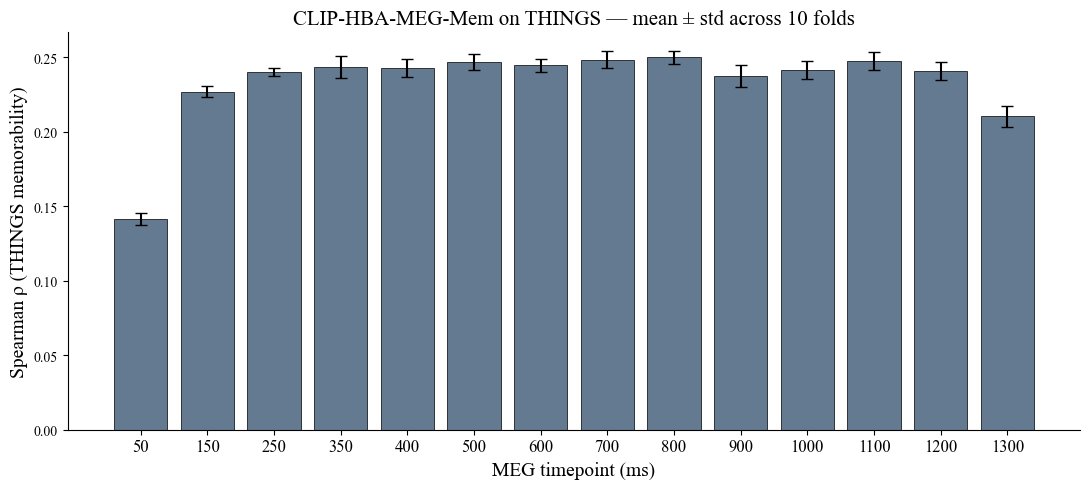

In [9]:
# --- Average Spearman rho across folds, per MEG timepoint ---
summary_path = Path("../preds/meg_mem/20260410_111733/summary.csv")
summary_df = pd.read_csv(summary_path)
print(f"Loaded {len(summary_df)} rows from {summary_path}")

# Average Spearman rho across folds for each timepoint
agg = (
    summary_df.groupby("timepoint_ms")["spearman_rho"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("timepoint_ms")
)
display(agg)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(agg))
ax.bar(
    x,
    agg["mean"].values,
    yerr=agg["std"].values,
    color="#49637E",
    alpha=0.85,
    capsize=4,
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xticks(x)
ax.set_xticklabels([f"{tp}" for tp in agg["timepoint_ms"]], fontsize=12)
ax.set_xlabel("MEG timepoint (ms)", fontsize=14)
ax.set_ylabel("Spearman ρ (THINGS memorability)", fontsize=14)
ax.set_title(
    f"CLIP-HBA-MEG-Mem on THINGS — mean ± std across {int(agg['count'].max())} folds",
    fontsize=15,
)
ax.axhline(0, color="black", linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = Path("meg_mem_things_spearman_by_timepoint.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {save_path.resolve()}")
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.font_manager as font_manager
from pathlib import Path 

plt.rcParams['font.family'] = 'Times New Roman'

meg_pred_dir = Path("../preds/meg_mem/20260410_111733")
pred_csvs = sorted(meg_pred_dir.glob("things_tp*_fold*_predictions.csv"))
print(f"Found {len(pred_csvs)} prediction CSVs in {meg_pred_dir}")

meg_preds_df = pd.concat([pd.read_csv(p) for p in pred_csvs], ignore_index=True)
print(f"Loaded {len(meg_preds_df):,} predictions across "
      f"{meg_preds_df['timepoint_ms'].nunique()} timepoints x "
      f"{meg_preds_df['fold'].nunique()} folds")

# Average pred_score across folds for each (timepoint, image)
meg_avg_df = (
    meg_preds_df.groupby(["timepoint_ms", "image_path"], as_index=False)
    .agg(pred_score_mean=("pred_score", "mean"),
         pred_score_std=("pred_score", "std"),
         n_folds=("pred_score", "count"),
         true_score=("true_score", "first"))
)

# Top-10 per timepoint by mean pred_score (deduplicated)
top10_per_tp = (
    meg_avg_df.sort_values(["timepoint_ms", "pred_score_mean"], ascending=[True, False])
    .groupby("timepoint_ms", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)
print(f"\nTop-10 most-memorable per timepoint (deduplicated): {len(top10_per_tp)} rows")
display(top10_per_tp[["timepoint_ms", "image_path", "pred_score_mean",
                       "pred_score_std", "n_folds", "true_score"]])

Found 140 prediction CSVs in ..\preds\meg_mem\20260410_111733
Loaded 3,654,840 predictions across 14 timepoints x 10 folds

Top-10 most-memorable per timepoint (deduplicated): 140 rows


,timepoint_ms,image_path,pred_score_mean,pred_score_std,n_folds,true_score
0,50,sequin_04s.jpg,0.963081,0.034172,10,0.897436
1,50,navel_03s.jpg,0.939110,0.019659,10,0.863636
2,50,needle_06s.jpg,0.938822,0.016387,10,0.853659
3,50,rosary_03s.jpg,0.937492,0.014589,10,0.825000
4,50,rust_10s.jpg,0.935860,0.010736,10,0.725000
...,...,...,...,...,...,...
135,1300,ankle_12s.jpg,0.969385,0.011945,10,0.875000
136,1300,saucer_01b.jpg,0.968821,0.016226,10,0.756098
137,1300,knee_05s.jpg,0.968100,0.010465,10,0.923077
138,1300,gauze_10s.jpg,0.966489,0.017600,10,0.842105


In [ ]:
# # --- Image grid: top-10 most memorable images per MEG timepoint ---
# # Each column is one timepoint, each row is rank 1..10 (top → bottom).

# things_img_dir = Path("Z:/multimodal_brain_inspired/THINGS_images")

# timepoints_to_plot = sorted(top10_per_tp["timepoint_ms"].unique())
# n_tps = len(timepoints_to_plot)
# n_rows = 10  # rank 1..10

# fig, axes = plt.subplots(
#     n_rows, n_tps,
#     figsize=(1.6 * n_tps, 1.6 * n_rows),
#     gridspec_kw={"wspace": 0.02, "hspace": 0.02},
# )
# # Force 2D indexing even if n_tps == 1
# if n_tps == 1:
#     axes = axes.reshape(-1, 1)

# for col, tp_ms in enumerate(timepoints_to_plot):
#     tp_rows = (
#         top10_per_tp[top10_per_tp["timepoint_ms"] == tp_ms]
#         .sort_values("pred_score_mean", ascending=False)
#         .reset_index(drop=True)
#     )

#     for row in range(n_rows):
#         ax = axes[row, col]
#         ax.set_xticks([])
#         ax.set_yticks([])
#         for spine in ax.spines.values():
#             spine.set_visible(False)

#         if row >= len(tp_rows):
#             ax.axis("off")
#             continue

#         image_name = tp_rows.loc[row, "image_path"]
#         # Derive concept from filename stem (strip trailing _NNx.jpg)
#         stem = Path(image_name).stem
#         concept = re.sub(r"_\d+[snb]$", "", stem)
#         img_path = things_img_dir / concept / image_name

#         if img_path.exists():
#             ax.imshow(mpimg.imread(str(img_path)))
#         else:
#             ax.text(0.5, 0.5, image_name, ha="center", va="center",
#                     fontsize=7, transform=ax.transAxes)

#         # Column header on the top row
#         if row == 0:
#             ax.set_title(f"{tp_ms} ms", fontsize=14, pad=6)
#         # Rank label on the left column
#         if col == 0:
#             ax.set_ylabel(f"#{row + 1}", fontsize=12, rotation=0,
#                           ha="right", va="center", labelpad=12)

# fig.suptitle(
#     "Top-10 most memorable THINGS images per MEG timepoint  "
#     "(mean pred_score across 10 folds)",
#     fontsize=15, y=0.995,
# )
# plt.tight_layout()

# save_path = Path("meg_mem_things_top10_grid.png")
# plt.savefig(save_path, dpi=200, bbox_inches="tight")
# print(f"Saved figure to {save_path.resolve()}")
# plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.font_manager as font_manager
from pathlib import Path 

plt.rcParams['font.family'] = 'Times New Roman'

meg_pred_dir = Path("../preds/meg_mem/20260410_111733")
pred_csvs = sorted(meg_pred_dir.glob("things_tp*_fold*_predictions.csv"))
print(f"Found {len(pred_csvs)} prediction CSVs in {meg_pred_dir}")

meg_preds_df = pd.concat([pd.read_csv(p) for p in pred_csvs], ignore_index=True)
print(f"Loaded {len(meg_preds_df):,} predictions across "
      f"{meg_preds_df['timepoint_ms'].nunique()} timepoints x "
      f"{meg_preds_df['fold'].nunique()} folds")

# Average pred_score across folds for each (timepoint, image)
meg_avg_df = (
    meg_preds_df.groupby(["timepoint_ms", "image_path"], as_index=False)
    .agg(pred_score_mean=("pred_score", "mean"),
         pred_score_std=("pred_score", "std"),
         n_folds=("pred_score", "count"),
         true_score=("true_score", "first"))
)

# Bottom-10 per timepoint by mean pred_score (deduplicated)
bottom10_per_tp = (
    meg_avg_df.sort_values(["timepoint_ms", "pred_score_mean"], ascending=False)
    .groupby("timepoint_ms", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)
print(f"\nBottom-10 least-memorable per timepoint (deduplicated): {len(bottom10_per_tp)} rows")
display(bottom10_per_tp[["timepoint_ms", "image_path", "pred_score_mean",
                       "pred_score_std", "n_folds", "true_score"]])

Found 140 prediction CSVs in ..\preds\meg_mem\20260410_111733
Loaded 3,654,840 predictions across 14 timepoints x 10 folds

Bottom-10 least-memorable per timepoint (deduplicated): 140 rows


,timepoint_ms,image_path,pred_score_mean,pred_score_std,n_folds,true_score
0,1300,needle_07s.jpg,0.987684,0.015479,10,0.794872
1,1300,ankle_04s.jpg,0.986245,0.011889,10,0.868421
2,1300,foot_02s.jpg,0.984389,0.014475,10,0.897436
3,1300,tortellini_11s.jpg,0.979701,0.011896,10,0.900000
4,1300,peppermint_06s.jpg,0.978307,0.013709,10,0.894737
...,...,...,...,...,...,...
135,50,paper_plate_06s.jpg,0.933029,0.022893,10,0.829268
136,50,shutter_11s.jpg,0.931355,0.014389,10,0.750000
137,50,chicken_wire_07s.jpg,0.929835,0.020379,10,0.842105
138,50,hot-water_bottle_10s.jpg,0.928702,0.016477,10,0.651163
